# General setup

In [1]:
import pandas as pd
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Environment setup

In [2]:
# Google Drive setup

from google.colab import drive
drive.mount('/content/drive')
files_base = '/content/drive/MyDrive/AI ML Certificate with Berkeley Haas/capstone/lendingclub'

Mounted at /content/drive


# Fetching Datasets

## Kaggle setup
This section does general setup for Kaggle that will be used for the LendingClub dataset as well as the S&P 500 dataset.

In [3]:
!pip install kaggle

In [4]:
# Get Kaggle username and API token, and make them available to the API
kaggle_username = input('Please enter your Kaggle username: ')
kaggle_api_token = input('Please enter your API token: ')
os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_api_token

download_path = os.path.join(files_base, 'kaggle')

Please enter your Kaggle username: jimshuma
Please enter your API token: KGAT_65408b1c24fcbce837ed433673bf766d


## Fetching the LendingClub dataset from Kaggle
This section pertains specifically to the LendingClub dataset.

In [5]:
skip_download_lendingclub = False
if not skip_download_lendingclub:
  from kaggle.api.kaggle_api_extended import KaggleApi
  dataset = 'wordsforthewise/lending-club'

  # Initialize API
  api = KaggleApi()
  api.authenticate()
  print('Authenticated to Kaggle')

  # Download dataset
  print(f'Downloading dataset {dataset} to {download_path}')
  api.dataset_download_files(dataset, path=download_path, unzip=True)
  print('Downloaded files')

Authenticated to Kaggle
Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
Downloaded files


In [6]:
# File paths (note subtle case differences)
accepted_filename = os.path.join(
    'accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv')
rejected_filename = os.path.join(
    'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv')
# gzipped input files are extracted into subfolders
accepted_path = os.path.join(download_path, accepted_filename)
rejected_path = os.path.join(download_path, rejected_filename)

In [7]:
# Load into Pandas
accepted_df = pd.read_csv(accepted_path, low_memory=False)
print("Accepted shape:", accepted_df.shape)

rejected_df = pd.read_csv(rejected_path, low_memory=False)
print("Rejected shape:", rejected_df.shape)

Accepted shape: (2260701, 151)
Rejected shape: (27648741, 9)


## Fetching the Federal Funds Effective rate dataset from the St. Louis Fed
The FEDFUNDS dataset is [available from the St. Louis Fed](https://fred.stlouisfed.org/series/FEDFUNDS). It is a simple dataset, providing a date and the percentage rate.

In [8]:
# Fetch a dataset from 2005-Jan through 2020-Jan, overlapping with the LendingClub dataset.
url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=FEDFUNDS&scale=left&cosd=2005-01-01&coed=2020-01-01&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-02-22&revision_date=2026-02-22&nd=1954-07-01'
fed_funds_df = pd.read_csv(url, parse_dates=['observation_date'])

## Fetching the S&P 500 dataset from Kaggle

In [9]:
skip_download_sp500 = False
if not skip_download_sp500:
  from kaggle.api.kaggle_api_extended import KaggleApi
  dataset = 'henryhan117/sp-500-historical-data'

  # Initialize API
  api = KaggleApi()
  api.authenticate()
  print('Authenticated to Kaggle')

  # Download dataset
  print(f'Downloading dataset {dataset} to {download_path}')
  api.dataset_download_files(dataset, path=download_path, unzip=True)
  print('Downloaded files')

Authenticated to Kaggle
Dataset URL: https://www.kaggle.com/datasets/henryhan117/sp-500-historical-data
Downloaded files


In [10]:
sp500_filename = 'SPX.csv'
sp500_path = os.path.join(download_path, sp500_filename)

sp500_df = pd.read_csv(sp500_path, parse_dates=["Date"])
print("S&P 500 shape: ", sp500_df.shape)

S&P 500 shape:  (23323, 7)


# Exploring the data

## LendingClub
This section is an exploration of the LendingClub dataset.

In [11]:
# Don't truncate these columns, even though there's a lot of them.
pd.set_option('display.max_rows', None)      # show all rows
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', 0)           # let it use full console width

In [12]:
accepted_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    id                                          object 
 1    member_id                                   float64
 2    loan_amnt                                   float64
 3    funded_amnt                                 float64
 4    funded_amnt_inv                             float64
 5    term                                        object 
 6    int_rate                                    float64
 7    installment                                 float64
 8    grade                                       object 
 9    sub_grade                                   object 
 10   emp_title                                   object 
 11   emp_length                                  object 
 12   home_ownership                              object 
 13   annual_inc

In [13]:
rejected_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27648741 entries, 0 to 27648740
Data columns (total 9 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Amount Requested      float64
 1   Application Date      object 
 2   Loan Title            object 
 3   Risk_Score            float64
 4   Debt-To-Income Ratio  object 
 5   Zip Code              object 
 6   State                 object 
 7   Employment Length     object 
 8   Policy Code           float64
dtypes: float64(3), object(6)
memory usage: 1.9+ GB


`accepted_df` and `rejected_df` use a different set of columns, with different names. Furthermore, the set of metrics in `rejected_df` is far less useful for making loan determinations (e.g., `accepted_df` contains `chargeoff_within_12_months`, presumably a highly useful measure of loan defaults, while `rejected_df` contains nothing comparable). And, `rejected_df` is not useful as training data because we cannot see actual borrower performance, since the loan was never issued.

Therefore, we choose to discard `rejected_df` and focus solely on `accepted_df`.

In [14]:
rejected_df = None
rejected_df_full = None

In [15]:
accepted_df.describe().T

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.931228,9190.245488,5.000000e+02,8000.0000,12900.000,20000.000000,4.000000e+04
funded_amnt,2260668.0,15041.664057,9188.413022,5.000000e+02,8000.0000,12875.000,20000.000000,4.000000e+04
funded_amnt_inv,2260668.0,15023.437745,9192.331679,0.000000e+00,8000.0000,12800.000,20000.000000,4.000000e+04
int_rate,2260668.0,13.092829,4.832138,5.310000e+00,9.4900,12.620,15.990000,3.099000e+01
installment,2260668.0,445.806823,267.173535,4.930000e+00,251.6500,377.990,593.320000,1.719830e+03
annual_inc,2260664.0,77992.428687,112696.199574,0.000000e+00,46000.0000,65000.000,93000.000000,1.100000e+08
dti,2258957.0,18.824196,14.183329,-1.000000e+00,11.8900,17.840,24.490000,9.990000e+02
delinq_2yrs,2260639.0,0.306879,0.867230,0.000000e+00,0.0000,0.000,0.000000,5.800000e+01
fico_range_low,2260668.0,698.588205,33.010376,6.100000e+02,675.0000,690.000,715.000000,8.450000e+02


In [16]:
accepted_df.sample(20).T

,225398,1899218,105622,589978,198656,1801641,153729,350535,1585482,1178412,147824,1256369,723801,1826125,610062,1026057,413802,1977500,1287853,1490500
id,55038558,1623989,62003373,115249128,56081590,7049303,59153308,42674533,130058217,28964060,59839407,19005983,77295898,6166747,114993526,73743921,38425543,88118537,14378013,135538708
member_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,25675.0,20000.0,10000.0,8000.0,12000.0,20000.0,6600.0,12500.0,12000.0,21600.0,8000.0,8375.0,12000.0,19350.0,12000.0,25000.0,12000.0,35000.0,12725.0,30000.0
funded_amnt,25675.0,20000.0,10000.0,8000.0,12000.0,20000.0,6600.0,12500.0,12000.0,21600.0,8000.0,8375.0,12000.0,19350.0,12000.0,25000.0,12000.0,35000.0,12725.0,30000.0
funded_amnt_inv,25675.0,19925.0,10000.0,8000.0,11950.0,20000.0,6600.0,12500.0,12000.0,21600.0,8000.0,8375.0,12000.0,19350.0,12000.0,25000.0,12000.0,35000.0,12725.0,30000.0
term,60 months,36 months,36 months,36 months,36 months,36 months,36 months,36 months,36 months,36 months,36 months,36 months,36 months,60 months,60 months,60 months,36 months,36 months,60 months,60 months
int_rate,13.33,14.09,8.18,20.0,13.33,6.62,11.53,9.99,7.34,10.15,12.69,22.15,5.32,11.55,9.44,11.99,10.49,15.59,19.99,11.05
installment,588.54,684.43,314.2,297.31,406.24,614.08,217.74,403.29,372.4,698.5,268.36,320.5,361.38,426.05,251.68,555.99,389.98,1223.43,337.07,653.03
grade,C,B,B,D,C,A,B,B,A,B,C,E,A,B,B,C,B,C,E,B
sub_grade,C3,B5,B1,D4,C3,A2,B5,B3,A4,B2,C2,E5,A1,B3,B1,C1,B3,C5,E1,B4


In [17]:
# Figure out how many NaNs we have to deal with.
nans_percentage = accepted_df.isna().mean() * 100
nans_percentage[nans_percentage > 20]

,0
member_id,100.000000
desc,94.423632
mths_since_last_delinq,51.246715
mths_since_last_record,84.113069
next_pymnt_d,59.509993
mths_since_last_major_derog,74.309960
annual_inc_joint,94.660506
dti_joint,94.660683
verification_status_joint,94.880791
open_acc_6m,38.313912


Interesting columns of `accepted_df` include:
- `loan_amnt`, `emp_length`, `annual_inc`, `dti`, `delinq_2yrs`, `earliest_cr_line`, `fico_range_low`, `inq_last_6mths`, `mths_since_last_delinq`, `open_acc`, `revol_bal`, `num_rev_accts`: These are categories traditionally considered very important for making lending decisions.
- `pub_rec_bankruptcies`, `tax_liens`: These are major red flags for lending—but perhaps also opportunities, for lenders who are willing to undertake extra risk in exchange for greater interest returns.
- `collections_12_mths_ex_med`, `mths_since_last_major_derog`: Also red flags that may signal higher returns in exchange for higher risk, but there are not enough rows with this data to provide meaningful signal.
- `zip_code`, `addr_state`: Zip code can potentially provide meaningful signal, but may also be correlated with other factors that could prove controversial in a manner similar to [redlining](https://en.wikipedia.org/wiki/Redlining). For the purposes of this analysis, `zip_code` will be excluded, but `addr_state` will be considered as a factor with low enough granularity to factor in all types of borrowers.
- `purpose`
- `int_rate`
- `grade`
- `loan_status`: The status of the loan in question. Can be any of the following values:
  - `Fully Paid`
  - `Current`
  - `Charged Off`
  - `In Grace Period`
  - `Late (16-30 days)`
  - `Late (31-120 days)`
  - `Does not meet the credit policy. Status:Fully Paid`
  - `Does not meet the credit policy. Status:Charged Off`
  - `Default`

In [18]:
# Drop columns that are 20%+ NaN. The data is too messy to use; and, as it turns
# out, these columns weren't useful anyway since they generally pertain to
# information only known during the duration of the loan, so they can't be used
# at lending decision time.
nan_columns_to_drop = accepted_df.columns[nans_percentage > 20]
print(nan_columns_to_drop)
accepted_df.drop(columns=nan_columns_to_drop, inplace=True)

# Now, drop rows that have a NaN anywhre in them
row_has_nan = accepted_df.isna().any(axis=1)
percent_rows_with_nan = row_has_nan.mean() * 100
print(f"{percent_rows_with_nan}% of rows have NaNs")

Index(['member_id', 'desc', 'mths_since_last_delinq', 'mths_since_last_record',
       'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint',
       'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_act_il',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'inq_fi', 'total_cu_tl', 'inq_last_12m', 'mths_since_recent_bc_dlq',
       'mths_since_recent_revol_delinq', 'revol_bal_joint',
       'sec_app_fico_range_low', 'sec_app_fico_range_high',
       'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
       'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
       'sec_app_open_act_il', 'sec_app_num_rev_accts',
       'sec_app_chargeoff_within_12_mths',
       'sec_app_collections_12_mths_ex_med',
       'sec_app_mths_since_last_major_derog', 'hardship_type',
       'hardship_reason', 'hardship_status', 'deferral_term',
       'hardship_amount'

Even after dropping columns with more than 20% NaN values, we still have to drop a very large amount of data due to presence of NaNs. Dropping this much data may end up skewing the analysis by dropping rows that are NaN.

However, since our central task is to examine traditional creditworthiness measures in the context of different economic data, we don't need to look at all those columns; we can simply rely on LendingClub's assessment of creditworthiness, as encoded in `grade` and `sub_grade`. By examining this, as well as the surrounding context of economic realities pointed to by the issue date (`issue_d`), we can perform this analysis.

In [19]:
accepted_df = accepted_df.copy()[['grade', 'sub_grade', 'issue_d', 'loan_status']].dropna()

### Analysis of loan grade

In [20]:
accepted_df[['grade', 'sub_grade']].value_counts()

grade  sub_grade
C      C1           145903
B      B5           140288
       B4           139793
       B3           131514
C      C2           131116
       C3           129193
       C4           127115
B      B2           126621
       B1           125341
C      C5           116726
A      A5           107617
       A4            95874
       A1            86790
D      D1            81787
A      A3            73184
D      D2            72899
A      A2            69562
D      D3            64819
       D4            56896
       D5            48023
E      E1            33573
       E2            29924
       E3            26708
       E4            22763
       E5            22671
F      F1            13413
       F2             9305
       F3             7791
       F4             6124
       F5             5167
G      G1             4106
       G2             2688
       G3             2094
       G4             1712
       G5             1568
Name: count, dtype: int64

It is evident that all sub-grades consist of a letter and a number; and that the letter of the sub-grade always corresponds to the grade column. Therefore, we can look only at sub_grade.

Platform documentation indicates that creditworthiness runs from A through F in descending order of creditworthiness; and from there, 1 through 5. Therefore we can normalize the data as 6 major grades (A through F) and 5 minor grades (1 through 5), for 30 total grades.

In [21]:
letter_order = ['A', 'B', 'C', 'D', 'E', 'F']
letter_rank = {letter: i for i, letter in enumerate(letter_order)}

letters = accepted_df['sub_grade'].str[0]
numbers = accepted_df['sub_grade'].str[1].astype(int)

accepted_df['grade_score'] = (
    (5 - letters.map(letter_rank)) * 5 + (6 - numbers)
)
print(accepted_df[['grade', 'sub_grade', 'grade_score']].sample(10))

        grade sub_grade  grade_score
1021469     A        A1         30.0
862179      A        A1         30.0
179167      A        A1         30.0
1134853     A        A4         27.0
1794607     C        C1         20.0
1002720     C        C1         20.0
1853830     A        A2         29.0
954989      C        C5         16.0
2237533     C        C3         18.0
2010893     A        A2         29.0


### Analysis of issue date

Similarly, we can normalize `issue_d` using a similar scheme. It is always a 3-letter abbreciated month ("Jan", "Feb", etc.) followed by a hyphen and then a 4-digit year.

In [22]:
print(accepted_df['issue_d'].unique())

['Dec-2015' 'Nov-2015' 'Oct-2015' 'Sep-2015' 'Aug-2015' 'Jul-2015'
 'Jun-2015' 'May-2015' 'Apr-2015' 'Mar-2015' 'Feb-2015' 'Jan-2015'
 'Mar-2018' 'Feb-2018' 'Jan-2018' 'Sep-2017' 'Aug-2017' 'Jul-2017'
 'Jun-2016' 'May-2016' 'Apr-2016' 'Sep-2018' 'Aug-2018' 'Jul-2018'
 'Jun-2017' 'May-2017' 'Apr-2017' 'Mar-2016' 'Feb-2016' 'Jan-2016'
 'Dec-2014' 'Nov-2014' 'Oct-2014' 'Sep-2014' 'Aug-2014' 'Jul-2014'
 'Jun-2014' 'May-2014' 'Apr-2014' 'Mar-2014' 'Feb-2014' 'Jan-2014'
 'Dec-2018' 'Nov-2018' 'Oct-2018' 'Jun-2018' 'May-2018' 'Apr-2018'
 'Dec-2011' 'Nov-2011' 'Oct-2011' 'Sep-2011' 'Aug-2011' 'Jul-2011'
 'Jun-2011' 'May-2011' 'Apr-2011' 'Mar-2011' 'Feb-2011' 'Jan-2011'
 'Dec-2010' 'Nov-2010' 'Oct-2010' 'Sep-2010' 'Aug-2010' 'Jul-2010'
 'Jun-2010' 'May-2010' 'Apr-2010' 'Mar-2010' 'Feb-2010' 'Jan-2010'
 'Dec-2009' 'Nov-2009' 'Oct-2009' 'Sep-2009' 'Aug-2009' 'Jul-2009'
 'Jun-2009' 'May-2009' 'Apr-2009' 'Mar-2009' 'Feb-2009' 'Jan-2009'
 'Dec-2008' 'Nov-2008' 'Oct-2008' 'Sep-2008' 'Aug-2008' 'Jul-2

In [23]:
# Standardize a function to convert datetime to a numerical index; we'll use the
# same system for this and for economic data. (We assume all years are leap
# years and all months have 31 days.)
def datetime_to_index(dt):
  return dt.year*366 + dt.month*31 + dt.day

accepted_df['issue_d_dt'] = pd.to_datetime(
    accepted_df['issue_d'], format='%b-%Y')
accepted_df['issue_d_month_index'] = datetime_to_index(
    accepted_df['issue_d_dt'].dt)

print(accepted_df[['issue_d', 'issue_d_dt', 'issue_d_month_index']].sample(10))

          issue_d issue_d_dt  issue_d_month_index
171716   Aug-2015 2015-08-01               737739
1381717  Dec-2018 2018-12-01               738961
211371   Jul-2015 2015-07-01               737708
1665672  Mar-2017 2017-03-01               738316
524801   Jan-2018 2018-01-01               738620
2145664  Oct-2017 2017-10-01               738533
1114047  Jan-2016 2016-01-01               737888
858815   Jul-2018 2018-07-01               738806
202755   Jul-2015 2015-07-01               737708
1967568  Aug-2016 2016-08-01               738105


### Analysis of loan status

Loan status is one of the central properties of the primary thing we'd like to predict, so it would be good to turn it into something other than the status string used here.

One option would be to use a one-hot encoding, using `pd.get_dummies`. This preserves the fact that these are five mutually exclusive values, without making any statements between them.

Another option is to treat this as ordinal, which preserves the semantics of some being better than the other. This comes with a certain amount of approximation, though, since the options are not strictly linear in a quantitative sense: For example, a loan that's fully paid is better than one that's merely current; and one that's current is better than one that's in its grace period; but the difference between the former pair is probably less than the difference between the latter pair. Despite this approximation, preserving the relative ordering between statuses is still helpful to a prospective lender make a decision on an application.

In [24]:
accepted_df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [25]:
accepted_df['loan_status'].dropna().value_counts()

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [26]:
# Let's ignore those very few non-compliant loans; not sure how to make heads or tails of those.
accepted_df = accepted_df[~accepted_df['loan_status'].isin([
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'])
]

In [27]:
loan_status_mapping = {
    "Fully Paid": 7,
    "Current": 6,
    "In Grace Period": 5,
    "Late (16-30 days)": 4,
    "Late (31-120 days)": 3,
    "Charged Off": 2,
    "Default" : 1
}

accepted_df['loan_status_code'] = accepted_df['loan_status'].dropna().map(loan_status_mapping).astype(int)

print("New column 'loan_status_code' created with the following value counts:")
print(accepted_df['loan_status_code'].value_counts())

New column 'loan_status_code' created with the following value counts:
loan_status_code
7    1076751
6     878317
2     268559
3      21467
5       8436
4       4349
1         40
Name: count, dtype: int64


<Axes: xlabel='issue_d_month_index', ylabel='Density'>

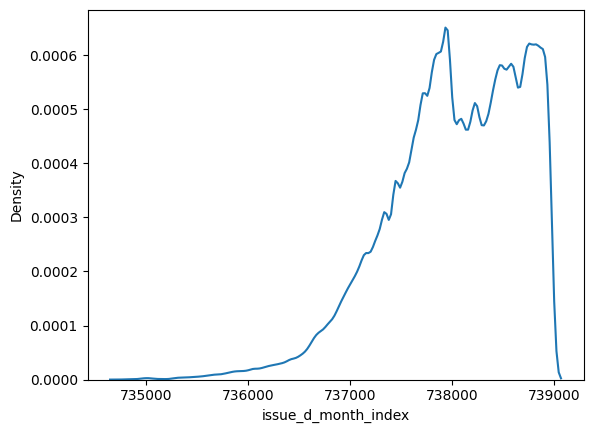

In [28]:
# We won't use loan origination dates until later, to correlate with the context
# of economic conditions. However, let's see when these loans were originated.
sns.kdeplot(
    data=accepted_df,
    x='issue_d_month_index')

### Completing the analysis

Now we have whittled down the dataset into four columns:

  - `grade_score`: A numerical value corresponding to creditworthiness (higher is better).
  - `issue_d_month_index`: The index of which month the loan was issued in.
  - `loan_status_code`: A numerical value corresponding to loan outcomes as of the time of the analysis (higher is better).

In [29]:
# There are still too many loan classes to make sense of;
# limit the visualization of busy graphs to the most common ones.
common_loans_df = accepted_df[accepted_df['loan_status_code'].isin([7, 6, 3])]

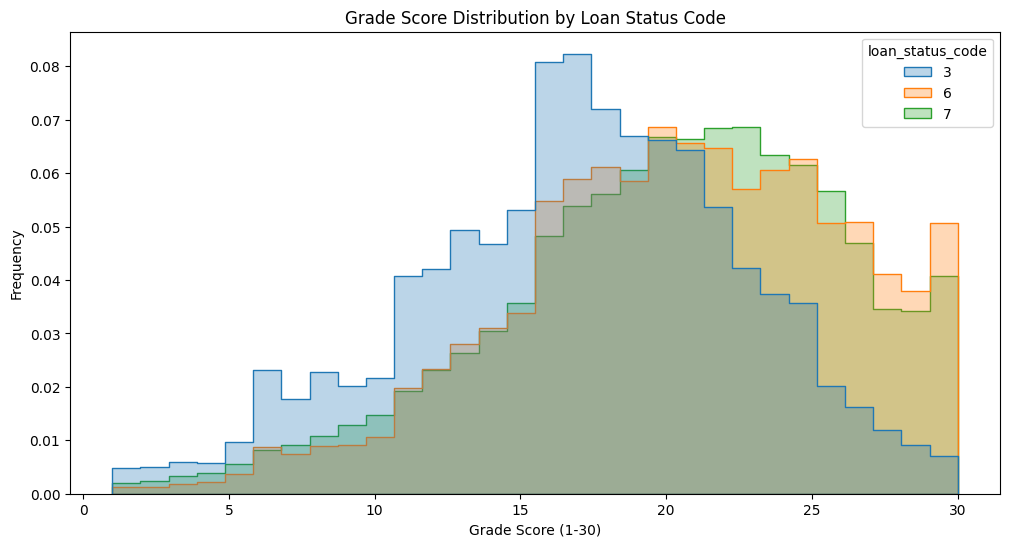

In [43]:
plt.figure(figsize=(12, 6))

# Create the overlapping histogram
sns.histplot(
    data=common_loans_df,
    x='grade_score',
    hue='loan_status_code',
    palette='tab10',
    bins=30,
    alpha=0.3,
    element='step',

    # density and common_norm amplify the less-common classes, so that the
    # overall statistics are visible.
    stat='density',
    common_norm=False
)

# Add labels and a title
plt.title('Grade Score Distribution by Loan Status Code')
plt.xlabel('Grade Score (1-30)')
plt.ylabel('Frequency')

# Show the plot
plt.show()

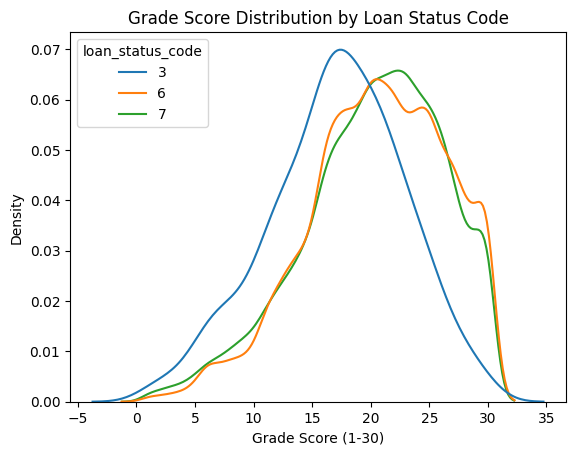

In [31]:
sns.kdeplot(
    data=common_loans_df,
    x='grade_score',
    hue='loan_status_code',
    palette='tab10',
    common_norm=False,

    # Discrete values cause a spurious squiggly apperance; smooth them
    bw_adjust=2
)

plt.title('Grade Score Distribution by Loan Status Code')
plt.xlabel('Grade Score (1-30)')
plt.ylabel('Density')

plt.show()

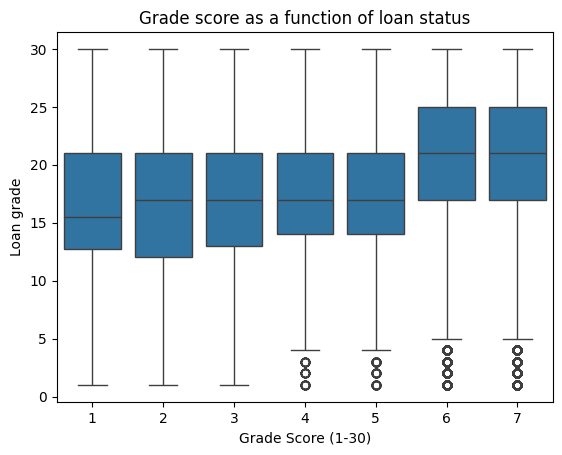

In [32]:
# This "inverted" analysis puts the dependent variable on the x-axis, in order
# to reduce visual noise and produce a more readable plot.

# Since this visualization isn't so busy, we use the full `accepted_df` rather
# than the stripped-down `common_loans_df`.
sns.boxplot(
    data=accepted_df,
    x='loan_status_code',
    y='grade_score'
  )

plt.title('Grade score as a function of loan status')
plt.xlabel('Grade Score (1-30)')
plt.ylabel('Loan grade')

plt.show()

From this analysis a clear picture emerges: Loans that were shown to have a lower grade at the time of application ended up having worse outcomes.

## Fed Funds Effective Rate

In [33]:
print(fed_funds_df.info())
print(fed_funds_df.describe())
print(fed_funds_df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  181 non-null    datetime64[ns]
 1   FEDFUNDS          181 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.0 KB
None
                    observation_date    FEDFUNDS
count                            181  181.000000
mean   2012-07-01 06:53:42.099447552    1.428453
min              2005-01-01 00:00:00    0.070000
25%              2008-10-01 00:00:00    0.130000
50%              2012-07-01 00:00:00    0.380000
75%              2016-04-01 00:00:00    2.280000
max              2020-01-01 00:00:00    5.260000
std                              NaN    1.720643
    observation_date  FEDFUNDS
155       2017-12-01      1.30
79        2011-08-01      0.10
64        2010-05-01      0.20
161       2018-06-01      1.82
180       2020-01-01

This dataset couldn't be much simpler; just a month (in datetime format) and funds rate (expressed as percentage points, with two decimal figures).

For comparing with LendingClub, we will want to add a column using the date indexing scheme from the LendingClub dataset.

In [34]:
fed_funds_df['observation_date_index'] = datetime_to_index(
    fed_funds_df['observation_date'].dt)

fed_funds_df.sample(5)

,observation_date,FEDFUNDS,observation_date_index
18,2006-07-01,5.24,734414
109,2014-02-01,0.07,737187
151,2017-08-01,1.16,738471
152,2017-09-01,1.15,738502
102,2013-07-01,0.09,736976


Sometimes what's interesting is the _rate of change_ rather than the funds rate itself. For example, when the rate is falling, this can be a sign of an impending recession; and when it's rising, it can be the result of the Fed acting to try and tame out-of-control growth. Both are suspected to be relevant to lending performance.

In [35]:
fed_funds_df['dFEDFUNDS'] = fed_funds_df['FEDFUNDS'].diff()
fed_funds_df.sample(5)

,observation_date,FEDFUNDS,observation_date_index,dFEDFUNDS
29,2007-06-01,5.25,734749,0.00
166,2018-11-01,2.20,738930,0.01
2,2005-03-01,2.63,733924,0.13
90,2012-07-01,0.16,736610,0.00
81,2011-10-01,0.07,736337,-0.01


Let's see what this looks like over time.

<Axes: xlabel='Date', ylabel='Percentage points'>

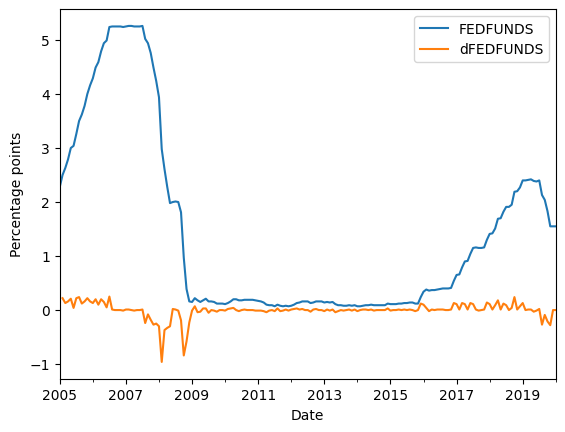

In [36]:
fed_funds_df.plot(
    x='observation_date',
    y=['FEDFUNDS', 'dFEDFUNDS'],
    xlabel='Date',
    ylabel='Percentage points',
    legend = True)

The most obvious features of this graph are the increases in rates around 2007 and 2017, and the sudden drop in 2008, consistent with the [2008 financial crisis](https://en.wikipedia.org/wiki/2008_financial_crisis).

## S&P 500

In [37]:
print(sp500_df.info())
print(sp500_df.describe())
print(sp500_df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23323 entries, 0 to 23322
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       23323 non-null  datetime64[ns]
 1   Open       23323 non-null  float64       
 2   High       23323 non-null  float64       
 3   Low        23323 non-null  float64       
 4   Close      23323 non-null  float64       
 5   Adj Close  23323 non-null  float64       
 6   Volume     23323 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 1.2 MB
None
                                Date          Open          High  \
count                          23323  23323.000000  23323.000000   
mean   1974-07-06 08:45:36.388972224    486.821737    489.690119   
min              1927-12-30 00:00:00      4.400000      4.400000   
25%              1951-05-05 12:00:00     23.855001     23.855001   
50%              1974-08-13 00:00:00     99.500000    1

While these are all interesting measures, the most important traditional signal for tracking market movement over time is the day's closing price (`Close`).

We will want to use the same date indexing scheme used in the previous two datasets.

In [38]:
sp500_df['Date_index'] = datetime_to_index(
    sp500_df['Date'].dt)

sp500_df.sample(5)

,Date,Open,High,Low,Close,Adj Close,Volume,Date_index
20434,2009-05-18,886.070007,910.000000,886.070007,909.710022,909.710022,5702150000,735467
6401,1953-08-14,24.620001,24.620001,24.620001,24.620001,24.620001,1000000,715060
20080,2007-12-19,1454.699951,1464.420044,1445.310059,1453.000000,1453.000000,3401300000,734953
12166,1976-08-11,104.410004,105.239998,103.730003,104.059998,104.059998,18710000,723475
22778,2018-09-07,2868.260010,2883.810059,2864.120117,2871.679932,2871.679932,2946270000,738874


Let's visualize over time.

<Axes: title={'center': 'S&P 500 closing price over time'}, xlabel='Date', ylabel='Closing price'>

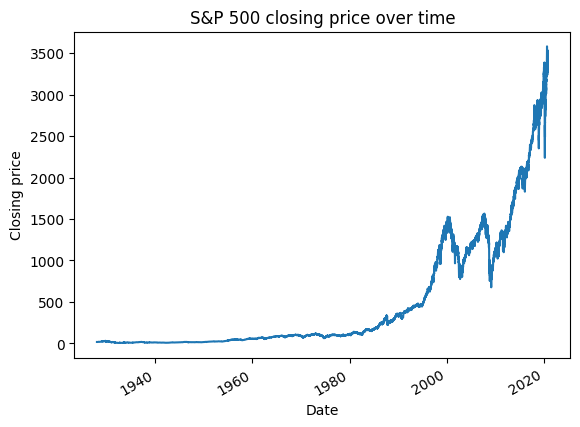

In [45]:
sp500_df.plot(
    x='Date',
    y='Close',
    xlabel='Date',
    ylabel='Closing price',
    title='S&P 500 closing price over time',
    legend = False)

That's a bit tough to visualize; let's see it on a logarithmic scale.

<Axes: title={'center': 'S&P 500 closing price over time (logarithmic scale)'}, xlabel='Date', ylabel='Closing price'>

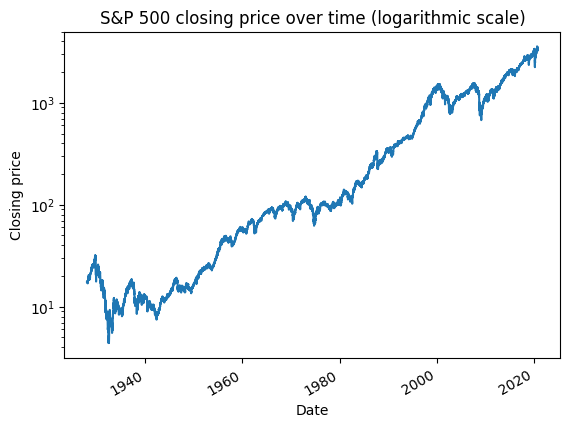

In [47]:
sp500_df.plot(
    x='Date',
    y='Close',
    xlabel='Date',
    ylabel='Closing price',
    title='S&P 500 closing price over time (logarithmic scale)',
    legend = False,
    logy = True)

Visually, this plot shows a roughly linear increase on a logrithmic scale, consistent with the familiar notion of long-term exponential growth in the stock market.

However, we may find that it's not the absolute price that matters for predicting loan payback performance, but historical performance. With that in mind, let's add a column for the historical average price over the last 2 years (approximated as 52 five-day weeks, times two), and one for how the closing price compares with historical averages. As a very rough measure, we take it as a positive sign when the stock market exceeds its recent average, and a negative sign when it lags behind.

In [41]:
yrs_to_average = 2
sp500_df['avg_close'] = sp500_df['Close'].rolling(yrs_to_average * 5*52).mean()
sp500_df['close_above_avg'] = sp500_df['Close'] - sp500_df['avg_close']

<Axes: title={'center': 'S&P 500 closing price with moving average, compared with performance above mean'}, xlabel='Date', ylabel='Price'>

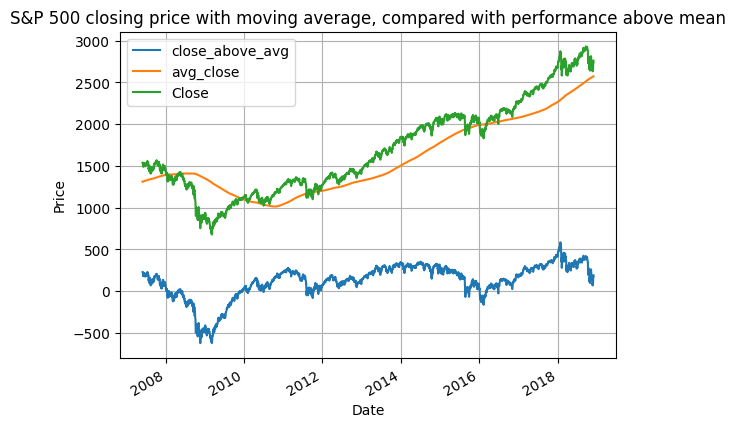

In [54]:
min_date = accepted_df['issue_d_dt'].min()
max_date = accepted_df['issue_d_dt'].max()

# Restrict to the timeframe we're interested in
sp500_df[(sp500_df['Date'] >= min_date) &
         (sp500_df['Date'] <= max_date)].plot(
    x='Date',
    y=['close_above_avg', 'avg_close', 'Close'],
    xlabel='Date',
    ylabel='Price',
    title='S&P 500 closing price with moving average, '
      'compared with performance above mean',
    legend = True,
    grid = True)

# Summary

We have obtained and explored three datasets:
- A dataset containing loan performance data from LendingClub.
- The effective Federal funds rate over time.
- S&P 500 performance over time.

The first of these datasets contains indicators that may be useful for predicting actual loan performance, but a follow-up analysis aims to analyze whether economic context is more important than borrower characteristics in determining actual loan performance.

To do this, the following approaches are expected to be used:
- A logistic regression model with the LendingClub dataset, to assess how accurately we can predict loan status as a function of borrower grade (which is itself determined by LendingClub's best efforts to model borrower characteristics in a simple measure).
  - It remains to be seen whether the model will be more accurate in predicting precisely which grade borrowers fall into, or in more-general cateogires (in which current and paid off are considered "good" while the various types of being late or in default are considered "bad").
- An ARMA process to model the effective Federal funds rate over time. (ARMA is more appropriate than ARIMA because the data is expected to be stationary, with no seasonal or long-term variation over time.)
- An ARIMA process to model the S&P 500. (ARIMA is more appropriate than ARMA, because the data is not expected to be stationary; it shows both seasonality (often captured glibly in the advice to "Sell in May and walk away") and long-term trends.

The analysis aims to train multiple models and compare their performance:
- The logistic regression model mentioned above, predicting borrower performance as a function of _only_ the borrower grade.
- Predicting borrower performance as a function of _only_ economic context. (For these purposes, we may analyze either the effective Federal funds rate, or the S&P 500 dataset, or a combination of both.)
- Predicting borrower performance as a function of _both_ borrower grade _and_ economic context.